## Gemini

In [1]:
'''
#视网膜数据
data = {
    #'SID': {'CC': None, 'MSE': 0.0112, 'PSNR': 27.0936, 'SSIM': 0.4772},
    'LN': {'CC': 0.5842, 'MSE': 0.0094, 'PSNR': 26.9859, 'SSIM': 0.4806},
    'GLM': {'CC': 0.7375, 'MSE': 0.0083, 'PSNR': 27.6223, 'SSIM': 0.5055},
    'CNN': {'CC': 0.7549, 'MSE': 0.0077, 'PSNR': 28.1648, 'SSIM': 0.5347}
}
'''

#皮层数据
data = {
    #'SID': {'CC': None, 'MSE': 0.0052, 'PSNR': 23.2688, 'SSIM': 0.7449},
    'LN': {'CC': 0.3963, 'MSE': 0.0071, 'PSNR': 22.0554, 'SSIM': 0.6857},
    'GLM': {'CC': 0.4573, 'MSE': 0.0055, 'PSNR': 23.0261, 'SSIM': 0.7246},
    'CNN': {'CC': 0.4750, 'MSE': 0.0040, 'PSNR': 24.0742, 'SSIM': 0.7729}
}

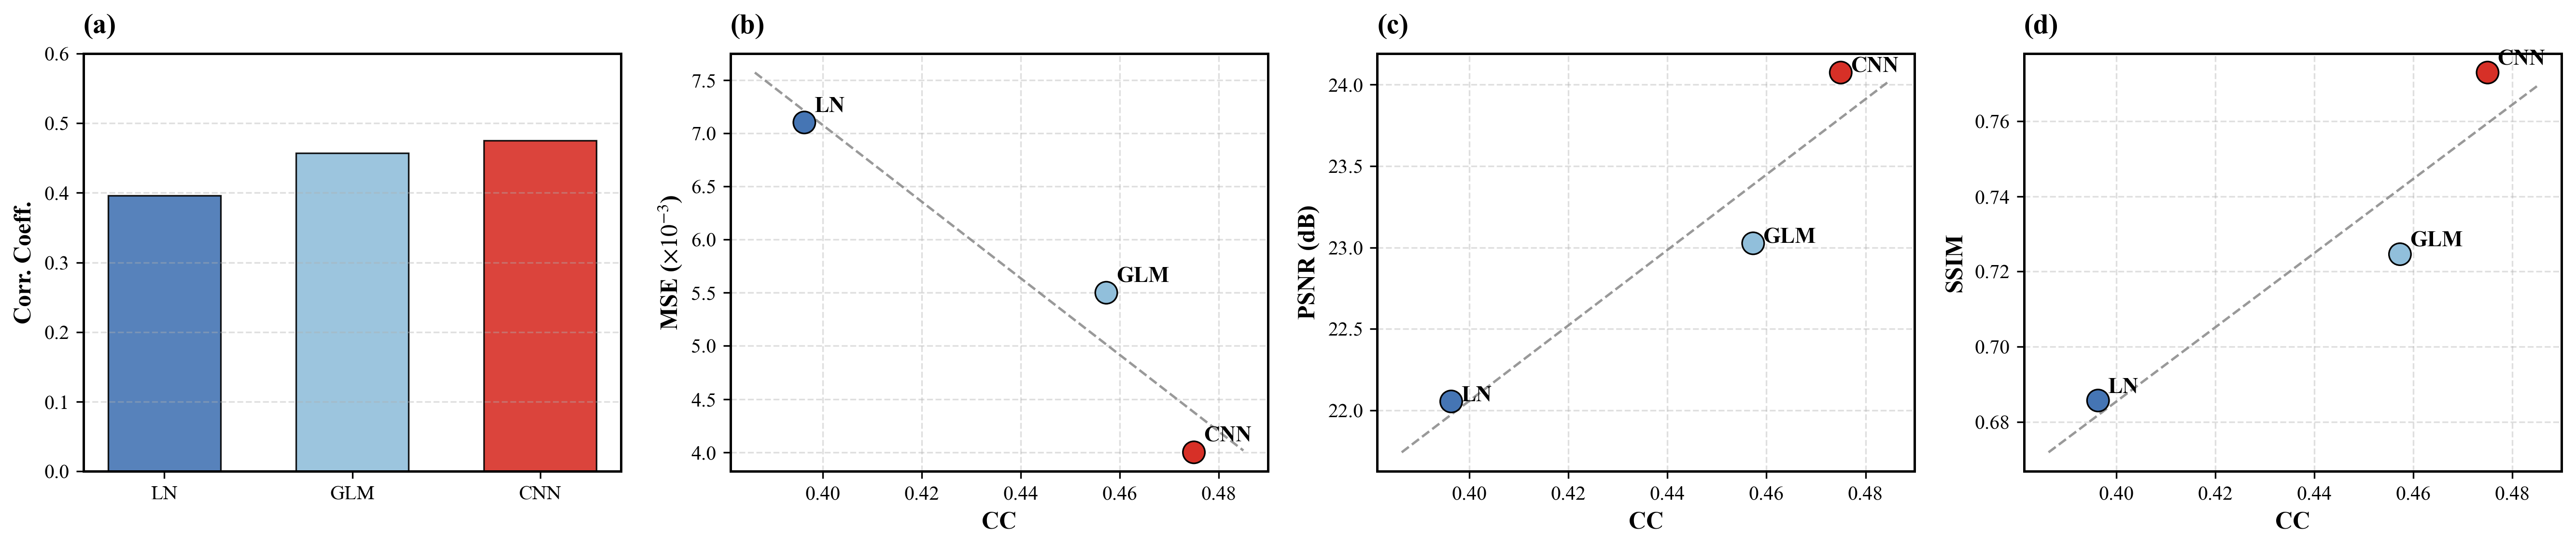

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter
from scipy import stats

# 模拟数据 (请确保你的原始数据变量 data, models, cc_array 等已定义)
models = ['LN', 'GLM', 'CNN']
cc_array = np.array([data['LN']['CC'], data['GLM']['CC'], data['CNN']['CC']])

# --- 论文级全局样式设置 ---
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth": 1.2,
    "mathtext.fontset": "stix" # 使数学公式更接近 Times 风格
})

# 1x4 布局：宽度加长，高度压缩以节省论文空间
fig, axes = plt.subplots(1, 4, figsize=(18, 4), dpi=300)
colors = ['#4575b4', '#91bfdb', '#d73027'] # 学术常用配色（深蓝、浅蓝、红）

# --- (a) Correlation Coefficient Bar Plot ---
ax0 = axes[0]
cc_vals = [data['LN']['CC'], data['GLM']['CC'], data['CNN']['CC']]
ax0.bar(models, cc_vals, color=colors, alpha=0.9, edgecolor='black', linewidth=0.8, width=0.6)
ax0.set_ylabel('Corr. Coeff.', fontweight='bold')
ax0.set_ylim(0, 0.6) # 适当压缩范围，减少上方留白
ax0.grid(axis='y', linestyle='--', alpha=0.4)
ax0.set_title('(a)', loc='left', pad=10, fontweight='bold')

# --- 通用的散点图绘制函数，减少重复代码并统一样式 ---
def plot_scatter_with_reg(ax, x_data, y_data, ylabel, label_letter, is_mse=False):
    # 散点
    ax.scatter(x_data, y_data, s=120, c=colors, edgecolors='black', linewidth=0.8, zorder=3)
    
    # 回归线
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_data, y_data)
    line_x = np.array([x_data.min() - 0.01, x_data.max() + 0.01])
    line_y = slope * line_x + intercept
    ax.plot(line_x, line_y, '--', color='gray', alpha=0.8, linewidth=1.2, zorder=2)
    
    # 模型标签：微调位置避免遮挡
    for i, m in enumerate(models):
        ax.text(x_data[i] + 0.002, y_data[i] + (0.002 if not is_mse else 0.0001), 
                m, fontsize=11, fontweight='bold')

    ax.set_xlabel('CC', fontweight='bold')
    ax.set_ylabel(ylabel, fontweight='bold')
    ax.set_title(label_letter, loc='left', pad=10, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4, zorder=1)
    
    # 强制四边框线，增加严谨感
    for spine in ax.spines.values():
        spine.set_visible(True)

# --- (b) MSE Plot ---
mse_array = np.array([data['LN']['MSE'], data['GLM']['MSE'], data['CNN']['MSE']])
plot_scatter_with_reg(axes[1], cc_array, mse_array, r'MSE ($\times 10^{-3}$)', '(b)', is_mse=True)
# 修正 MSE 的刻度显示，确保为 4.00, 6.00 等格式 [cite: 25-30]
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x*1e3:.1f}'))

# --- (c) PSNR Plot ---
psnr_array = np.array([data['LN']['PSNR'], data['GLM']['PSNR'], data['CNN']['PSNR']])
plot_scatter_with_reg(axes[2], cc_array, psnr_array, 'PSNR (dB)', '(c)')

# --- (d) SSIM Plot ---
ssim_array = np.array([data['LN']['SSIM'], data['GLM']['SSIM'], data['CNN']['SSIM']])
plot_scatter_with_reg(axes[3], cc_array, ssim_array, 'SSIM', '(d)')

# --- 细节优化 ---
plt.tight_layout(pad=1.5) # 自动调整布局，减少外部留白

# 保存为矢量图 PDF 是顶会投稿的标配
#plt.savefig('academic_figure_1x4.pdf', bbox_inches='tight')
plt.show()

#print('论文级插图已保存为 academic_figure_1x4.pdf')

## Kimi

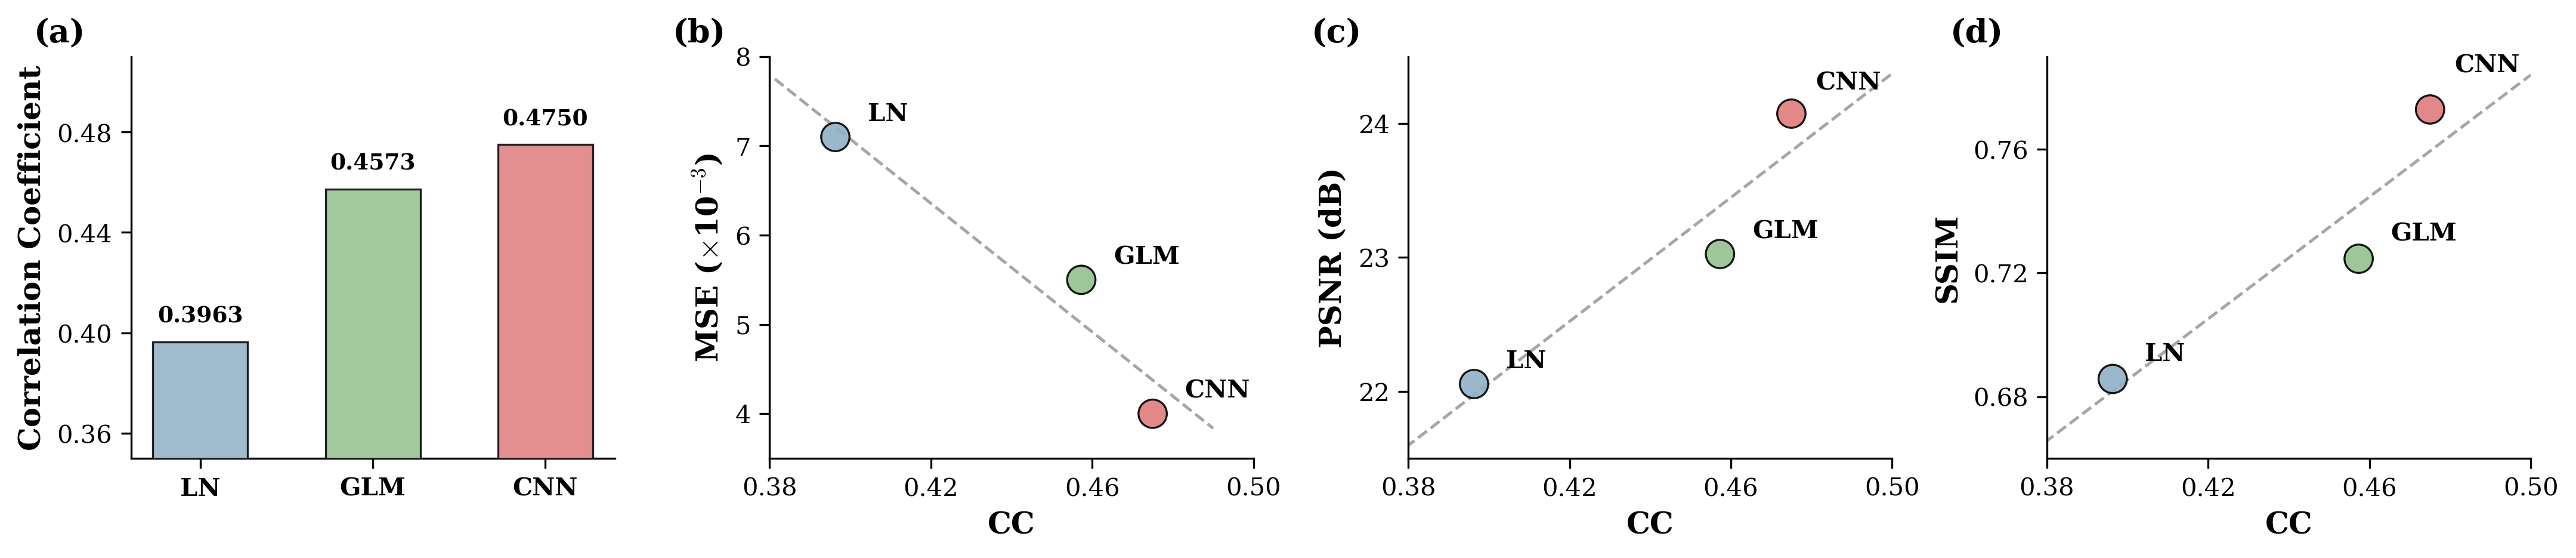

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from scipy import stats

# ============================================================
# 全局设置：LaTeX 风格字体 + 学术级参数
# ============================================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Computer Modern', 'DejaVu Serif'],
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.format': 'pdf',
    'text.usetex': False,
    'mathtext.fontset': 'cm',
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.minor.width': 0.5,
    'ytick.minor.width': 0.5,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.minor.size': 2,
    'ytick.minor.size': 2,
})

# ============================================================
# 数据准备
# ============================================================
#皮层数据
data = {
    'LN':  {'CC': 0.3963, 'MSE': 0.0071, 'PSNR': 22.0554, 'SSIM': 0.6857},
    'GLM': {'CC': 0.4573, 'MSE': 0.0055, 'PSNR': 23.0261, 'SSIM': 0.7246},
    'CNN': {'CC': 0.4750, 'MSE': 0.0040, 'PSNR': 24.0742, 'SSIM': 0.7729}
}


#视网膜数据
'''
data = {
    'LN': {'CC': 0.5842, 'MSE': 0.0094, 'PSNR': 26.9859, 'SSIM': 0.4806},
    'GLM': {'CC': 0.7375, 'MSE': 0.0083, 'PSNR': 27.6223, 'SSIM': 0.5055},
    'CNN': {'CC': 0.7549, 'MSE': 0.0077, 'PSNR': 28.1648, 'SSIM': 0.5347}
}
'''


models = ['LN', 'GLM', 'CNN']
cc_array = np.array([data[m]['CC'] for m in models])
mse_array = np.array([data[m]['MSE'] for m in models])
psnr_array = np.array([data[m]['PSNR'] for m in models])
ssim_array = np.array([data[m]['SSIM'] for m in models])

# 学术级配色（基于图像参考：LN红, GLM绿, CNN蓝）
#colors = ["#B52424", "#3E8E3E", "#3F6C8D"]
colors = ["#8FAFC6", "#93C08E", "#E07B7B"]
alpha = 0.9

# ============================================================
# 创建 1×4 横向布局
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(14.5, 3.4), dpi=300)

# 调整子图间距
plt.subplots_adjust(left=0.06, right=0.985, bottom=0.22, top=0.88, wspace=0.32)

# ============================================================
# Plot 1: CC Bar plot
# ============================================================
ax1 = axes[0]
cc_vals = [data[m]['CC'] for m in models]
bars = ax1.bar(models, cc_vals, color=colors, alpha=0.85, edgecolor='black', 
               linewidth=0.8, width=0.55, zorder=3)

# 数值标注
for bar, val in zip(bars, cc_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.006, 
             f'{val:.4f}', ha='center', va='bottom', fontsize=9, 
             fontweight='bold', color='black', zorder=4)

ax1.set_ylabel('Correlation Coefficient', fontsize=12, fontweight='bold')
ax1.set_ylim(0.35, 0.51)
ax1.set_yticks([0.36, 0.40, 0.44, 0.48])
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.tick_params(axis='both', which='major', labelsize=10, direction='out')
ax1.set_xticks(range(len(models)))
ax1.set_xticklabels(models, fontsize=10, fontweight='bold')

ax1.text(-0.20, 1.02, '(a)', transform=ax1.transAxes, fontsize=13, 
         fontweight='bold', va='bottom', ha='left')

# ============================================================
# Plot 2: MSE vs CC
# ============================================================
ax2 = axes[1]
ax2.scatter(cc_array, mse_array*1e3, s=130, alpha=0.9, color=colors, 
            edgecolors='black', linewidth=0.8, zorder=4)

# 线性拟合趋势线
slope, intercept, r_value, p_value, std_err = stats.linregress(cc_array, mse_array*1e3)
line_x = np.array([cc_array.min() - 0.015, cc_array.max() + 0.015])
line_y = slope * line_x + intercept
ax2.plot(line_x, line_y, '--', color='gray', alpha=0.7, linewidth=1.2, zorder=2)

# 标签统一右上方偏移
for i, m in enumerate(models):
    ax2.text(cc_array[i] + 0.008, mse_array[i]*1e3 + 0.18, m, 
             fontsize=10, ha='left', fontweight='bold', color='black')

ax2.set_xlabel('CC', fontsize=12, fontweight='bold')
ax2.set_ylabel('MSE ($\\times$10$^{-3}$)', fontsize=12, fontweight='bold')
ax2.set_xlim(0.38, 0.50)
ax2.set_ylim(3.5, 8.0)
ax2.set_xticks([0.38, 0.42, 0.46, 0.50])
ax2.set_yticks([4, 5, 6, 7, 8])
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.tick_params(axis='both', which='major', labelsize=10, direction='out')
ax2.text(-0.20, 1.02, '(b)', transform=ax2.transAxes, fontsize=13, 
         fontweight='bold', va='bottom', ha='left')

# ============================================================
# Plot 3: PSNR vs CC
# ============================================================
ax3 = axes[2]
ax3.scatter(cc_array, psnr_array, s=130, alpha=0.9, color=colors, 
            edgecolors='black', linewidth=0.8, zorder=4)

# 线性拟合线
slope, intercept, r_value, p_value, std_err = stats.linregress(cc_array, psnr_array)
line_x = np.array([0.37, 0.50])
line_y = slope * line_x + intercept
ax3.plot(line_x, line_y, '--', color='gray', alpha=0.7, linewidth=1.2, zorder=2)

# 标签统一右上方偏移（CNN 减小 x 偏移避免出界，增大 y 偏移往上走）
for i, m in enumerate(models):
    offset_x = 0.006 if m == 'CNN' else 0.008
    offset_y = 0.18 if m == 'CNN' else 0.12
    ax3.text(cc_array[i] + offset_x, psnr_array[i] + offset_y, m, 
             fontsize=10, ha='left', fontweight='bold', color='black')

ax3.set_xlabel('CC', fontsize=12, fontweight='bold')
ax3.set_ylabel('PSNR (dB)', fontsize=12, fontweight='bold')
ax3.set_xlim(0.38, 0.50)
ax3.set_ylim(21.5, 24.5)
ax3.set_xticks([0.38, 0.42, 0.46, 0.50])
ax3.set_yticks([22, 23, 24])
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.tick_params(axis='both', which='major', labelsize=10, direction='out')
ax3.text(-0.20, 1.02, '(c)', transform=ax3.transAxes, fontsize=13, 
         fontweight='bold', va='bottom', ha='left')

# ============================================================
# Plot 4: SSIM vs CC
# ============================================================
ax4 = axes[3]
ax4.scatter(cc_array, ssim_array, s=130, alpha=0.9, color=colors, 
            edgecolors='black', linewidth=0.8, zorder=4)

# 线性拟合线
slope, intercept, r_value, p_value, std_err = stats.linregress(cc_array, ssim_array)
line_x = np.array([0.37, 0.50])
line_y = slope * line_x + intercept
ax4.plot(line_x, line_y, '--', color='gray', alpha=0.7, linewidth=1.2, zorder=2)

# 标签统一右上方偏移（CNN 减小 x 偏移避免出界，增大 y 偏移往上走）
for i, m in enumerate(models):
    offset_x = 0.006 if m == 'CNN' else 0.008
    offset_y = 0.012 if m == 'CNN' else 0.006
    ax4.text(cc_array[i] + offset_x, ssim_array[i] + offset_y, m, 
             fontsize=10, ha='left', fontweight='bold', color='black')

ax4.set_xlabel('CC', fontsize=12, fontweight='bold')
ax4.set_ylabel('SSIM', fontsize=12, fontweight='bold')
ax4.set_xlim(0.38, 0.50)
ax4.set_ylim(0.66, 0.79)
ax4.set_xticks([0.38, 0.42, 0.46, 0.50])
ax4.set_yticks([0.68, 0.72, 0.76])
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.tick_params(axis='both', which='major', labelsize=10, direction='out')
ax4.text(-0.20, 1.02, '(d)', transform=ax4.transAxes, fontsize=13, 
         fontweight='bold', va='bottom', ha='left')

# ============================================================
# 保存
# ============================================================
plt.savefig('combined_1x4_Allen_final.pdf', dpi=300, bbox_inches='tight', 
            format='pdf', metadata={'Creator': 'Matplotlib'})
plt.savefig('combined_1x4_Allen_final.png', dpi=300, bbox_inches='tight',
            format='png')
plt.show()

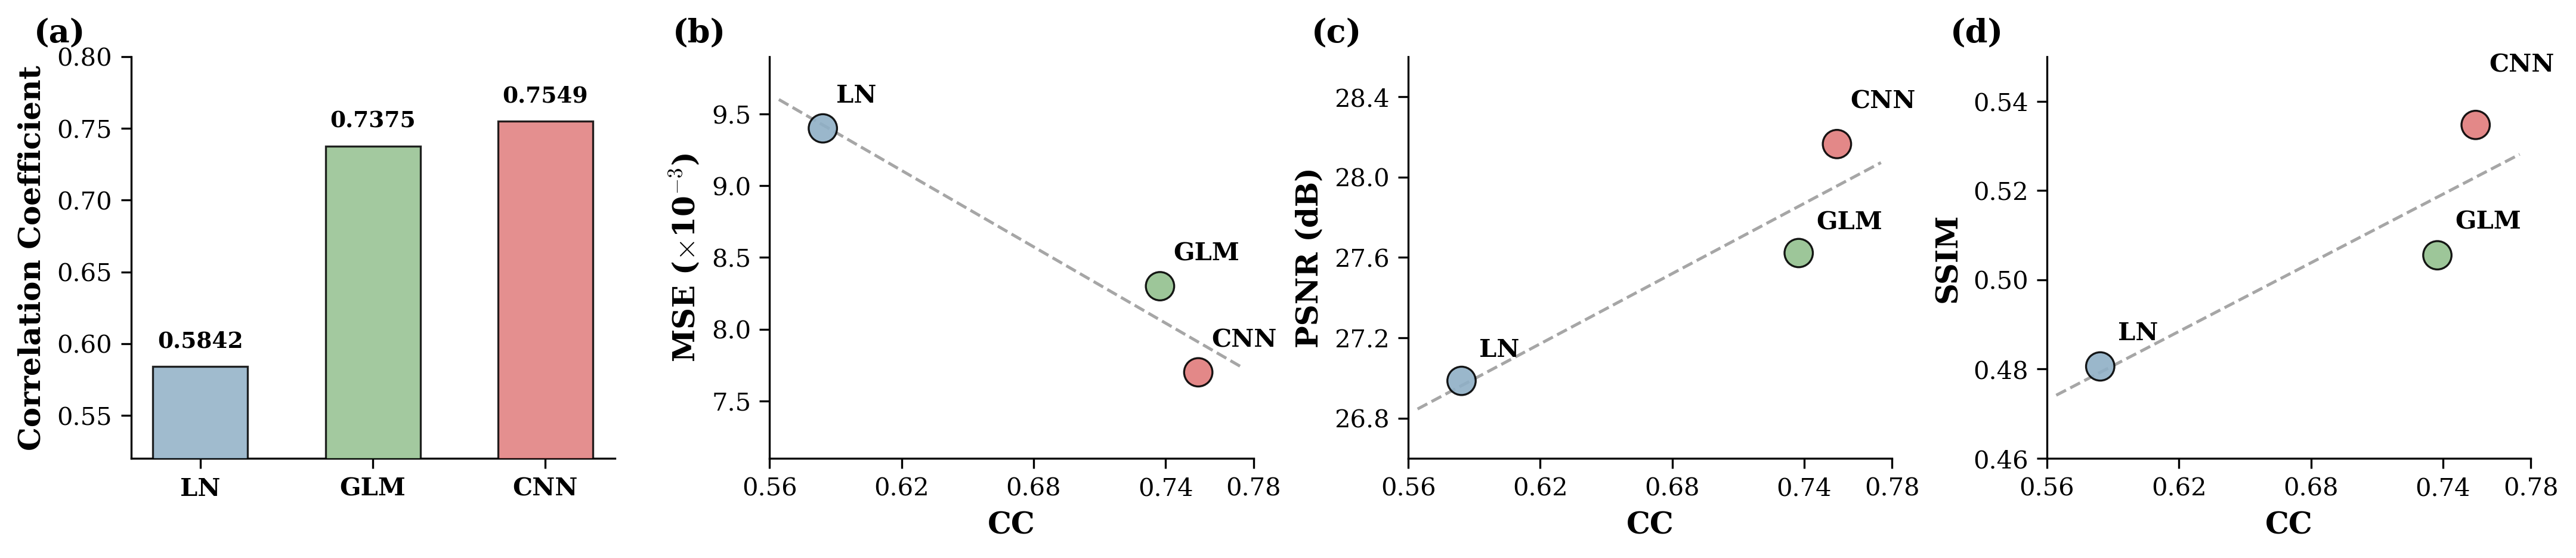

In [13]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from scipy import stats

# ============================================================
# 全局设置：LaTeX 风格字体 + 学术级参数
# ============================================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Computer Modern', 'DejaVu Serif'],
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.format': 'pdf',
    'text.usetex': False,
    'mathtext.fontset': 'cm',
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.minor.width': 0.5,
    'ytick.minor.width': 0.5,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.minor.size': 2,
    'ytick.minor.size': 2,
})

# ============================================================
# 数据准备：视网膜数据
# ============================================================
data = {
    'LN':  {'CC': 0.5842, 'MSE': 0.0094, 'PSNR': 26.9859, 'SSIM': 0.4806},
    'GLM': {'CC': 0.7375, 'MSE': 0.0083, 'PSNR': 27.6223, 'SSIM': 0.5055},
    'CNN': {'CC': 0.7549, 'MSE': 0.0077, 'PSNR': 28.1648, 'SSIM': 0.5347}
}

models = ['LN', 'GLM', 'CNN']
cc_array = np.array([data[m]['CC'] for m in models])
mse_array = np.array([data[m]['MSE'] for m in models])
psnr_array = np.array([data[m]['PSNR'] for m in models])
ssim_array = np.array([data[m]['SSIM'] for m in models])

# 视网膜版本的配色：保持 LN/GLM/CNN 一致
colors = ['#8FAFC6', '#93C08E', '#E07B7B']

# ============================================================
# 创建 1×4 横向布局
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(14.5, 3.4), dpi=300)
plt.subplots_adjust(left=0.06, right=0.985, bottom=0.22, top=0.88, wspace=0.32)

# ============================================================
# Plot 1: CC Bar plot
# ============================================================
ax1 = axes[0]
cc_vals = [data[m]['CC'] for m in models]
bars = ax1.bar(models, cc_vals, color=colors, alpha=0.85, edgecolor='black',
               linewidth=0.8, width=0.55, zorder=3)

for bar, val in zip(bars, cc_vals):
    ax1.text(bar.get_x() + bar.get_width() / 2, val + 0.01,
             f'{val:.4f}', ha='center', va='bottom', fontsize=9,
             fontweight='bold', color='black', zorder=4)

ax1.set_ylabel('Correlation Coefficient', fontsize=12, fontweight='bold')
ax1.set_ylim(0.52, 0.80)
ax1.set_yticks([0.55, 0.60, 0.65, 0.70, 0.75, 0.80])
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.tick_params(axis='both', which='major', labelsize=10, direction='out')
ax1.set_xticks(range(len(models)))
ax1.set_xticklabels(models, fontsize=10, fontweight='bold')
ax1.text(-0.20, 1.02, '(a)', transform=ax1.transAxes, fontsize=13,
         fontweight='bold', va='bottom', ha='left')

# ============================================================
# Plot 2: MSE vs CC
# ============================================================
ax2 = axes[1]
ax2.scatter(cc_array, mse_array * 1e3, s=130, alpha=0.9, color=colors,
            edgecolors='black', linewidth=0.8, zorder=4)

slope, intercept, r_value, p_value, std_err = stats.linregress(cc_array, mse_array * 1e3)
line_x = np.array([cc_array.min() - 0.02, cc_array.max() + 0.02])
line_y = slope * line_x + intercept
ax2.plot(line_x, line_y, '--', color='gray', alpha=0.7, linewidth=1.2, zorder=2)

for i, m in enumerate(models):
    ax2.text(cc_array[i] + 0.006, mse_array[i] * 1e3 + 0.18, m,
             fontsize=10, ha='left', fontweight='bold', color='black')

ax2.set_xlabel('CC', fontsize=12, fontweight='bold')
ax2.set_ylabel('MSE ($\\times$10$^{-3}$)', fontsize=12, fontweight='bold')
ax2.set_xlim(0.56, 0.78)
ax2.set_ylim(7.1, 9.9)
ax2.set_xticks([0.56, 0.62, 0.68, 0.74, 0.78])
ax2.set_yticks([7.5, 8.0, 8.5, 9.0, 9.5])
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.tick_params(axis='both', which='major', labelsize=10, direction='out')
ax2.text(-0.20, 1.02, '(b)', transform=ax2.transAxes, fontsize=13,
         fontweight='bold', va='bottom', ha='left')

# ============================================================
# Plot 3: PSNR vs CC
# ============================================================
ax3 = axes[2]
ax3.scatter(cc_array, psnr_array, s=130, alpha=0.9, color=colors,
            edgecolors='black', linewidth=0.8, zorder=4)

slope, intercept, r_value, p_value, std_err = stats.linregress(cc_array, psnr_array)
line_x = np.array([cc_array.min() - 0.02, cc_array.max() + 0.02])
line_y = slope * line_x + intercept
ax3.plot(line_x, line_y, '--', color='gray', alpha=0.7, linewidth=1.2, zorder=2)

for i, m in enumerate(models):
    offset_x = 0.006 if m == 'CNN' else 0.008
    offset_y = 0.18 if m == 'CNN' else 0.12
    ax3.text(cc_array[i] + offset_x, psnr_array[i] + offset_y, m,
             fontsize=10, ha='left', fontweight='bold', color='black')

ax3.set_xlabel('CC', fontsize=12, fontweight='bold')
ax3.set_ylabel('PSNR (dB)', fontsize=12, fontweight='bold')
ax3.set_xlim(0.56, 0.78)
ax3.set_ylim(26.6, 28.6)
ax3.set_xticks([0.56, 0.62, 0.68, 0.74, 0.78])
ax3.set_yticks([26.8, 27.2, 27.6, 28.0, 28.4])
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.tick_params(axis='both', which='major', labelsize=10, direction='out')
ax3.text(-0.20, 1.02, '(c)', transform=ax3.transAxes, fontsize=13,
         fontweight='bold', va='bottom', ha='left')

# ============================================================
# Plot 4: SSIM vs CC
# ============================================================
ax4 = axes[3]
ax4.scatter(cc_array, ssim_array, s=130, alpha=0.9, color=colors,
            edgecolors='black', linewidth=0.8, zorder=4)

slope, intercept, r_value, p_value, std_err = stats.linregress(cc_array, ssim_array)
line_x = np.array([cc_array.min() - 0.02, cc_array.max() + 0.02])
line_y = slope * line_x + intercept
ax4.plot(line_x, line_y, '--', color='gray', alpha=0.7, linewidth=1.2, zorder=2)

for i, m in enumerate(models):
    offset_x = 0.006 if m == 'CNN' else 0.008
    offset_y = 0.012 if m == 'CNN' else 0.006
    ax4.text(cc_array[i] + offset_x, ssim_array[i] + offset_y, m,
             fontsize=10, ha='left', fontweight='bold', color='black')

ax4.set_xlabel('CC', fontsize=12, fontweight='bold')
ax4.set_ylabel('SSIM', fontsize=12, fontweight='bold')
ax4.set_xlim(0.56, 0.78)
ax4.set_ylim(0.46, 0.55)
ax4.set_xticks([0.56, 0.62, 0.68, 0.74, 0.78])
ax4.set_yticks([0.46, 0.48, 0.50, 0.52, 0.54])
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.tick_params(axis='both', which='major', labelsize=10, direction='out')
ax4.text(-0.20, 1.02, '(d)', transform=ax4.transAxes, fontsize=13,
         fontweight='bold', va='bottom', ha='left')

# ============================================================
# 保存
# ============================================================
plt.savefig('combined_1x4_retina_final.pdf', dpi=300, bbox_inches='tight', format='pdf', metadata={'Creator': 'Matplotlib'})
plt.savefig('combined_1x4_retina_final.png', dpi=300, bbox_inches='tight', format='png')
plt.show()